In [1]:
#load dataset containing CO2 emmisions
import pandas as pd
data= pd.read_csv('owid-co2-data.csv')



In [2]:
#data shape?
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 79 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   country                                    50411 non-null  object 
 1   year                                       50411 non-null  int64  
 2   iso_code                                   42480 non-null  object 
 3   population                                 41167 non-null  float64
 4   gdp                                        15251 non-null  float64
 5   cement_co2                                 29173 non-null  float64
 6   cement_co2_per_capita                      25648 non-null  float64
 7   co2                                        29384 non-null  float64
 8   co2_growth_abs                             27216 non-null  float64
 9   co2_growth_prct                            26239 non-null  float64
 10  co2_including_luc     

In [3]:
#shape of dataset
data.shape

(50411, 79)

In [4]:
#top 10 by total C02 emissions in most recent recorded year (2024)
latest_year = data[data['year']==2024]
latest_year[['country', 'co2']].sort_values('co2', ascending=False).head(10)
#note that we need to filter out aggregates so we have countires only



,country,co2
49785,World,38598.578
33560,Non-OECD (GCP),26233.051
2953,Asia,23392.488
3128,Asia (GCP),20432.227
48282,Upper-middle-income countries,18237.494
20669,High-income countries,13867.993
9933,China,12289.037
35085,OECD (GCP),11173.062
3403,Asia (excl. China and India),7909.973
33835,North America,6084.276


In [5]:
latest_year = data[data['year']==2024]
countries= latest_year[latest_year['iso_code'].str.len()==3]
countries[['country', 'co2']].sort_values('co2', ascending=False).head(10)
#Top 10 countries net total co2 emissions in 2024 per country

,country,co2
9933,China,12289.037
48007,United States,4904.120
21762,India,3193.478
38314,Russia,1780.524
23812,Japan,961.867
21937,Indonesia,812.220
22662,Iran,792.631
40289,Saudi Arabia,692.133
43038,South Korea,583.679
18319,Germany,572.319


Net total emissions and emission-per-capita are different. The highest emission-per-capita are mostly the oil-rich middle eastern nations.

In [6]:
#what about by co2 per capita?
countries[['country', 'co2_per_capita']].sort_values('co2_per_capita', ascending=False).head(10)
#Top per capita emitters are mostly oil rich counties lcoated in the middle east. Qatar is the highest, at 41.3 tonnes per person
#China is not in this list, despite being the leader in total co2 emission in 2024.


,country,co2_per_capita
37960,Qatar,41.271
24865,Kuwait,26.248
7662,Brunei,26.046
4514,Bahrain,24.270
45799,Trinidad and Tobago,22.932
40289,Saudi Arabia,20.379
47507,United Arab Emirates,20.131
32410,New Caledonia,18.064
41538,Sint Maarten (Dutch part),16.546
35885,Oman,15.651


In [7]:
#global co2 emssion trends over time
world = data[data['country']=='World']
#keep only year and total c02
world_co2= world[['year', 'co2']].dropna()

world_co2.tail(10)
#notice the decrease in 2020 from 2019, likely due to the pandemic lockdowns.

,year,co2
49776,2015,35403.527
49777,2016,35392.832
49778,2017,35974.609
49779,2018,36734.004
49780,2019,37086.566
49781,2020,35158.230
49782,2021,36866.863
49783,2022,37527.773
49784,2023,38094.039
49785,2024,38598.578


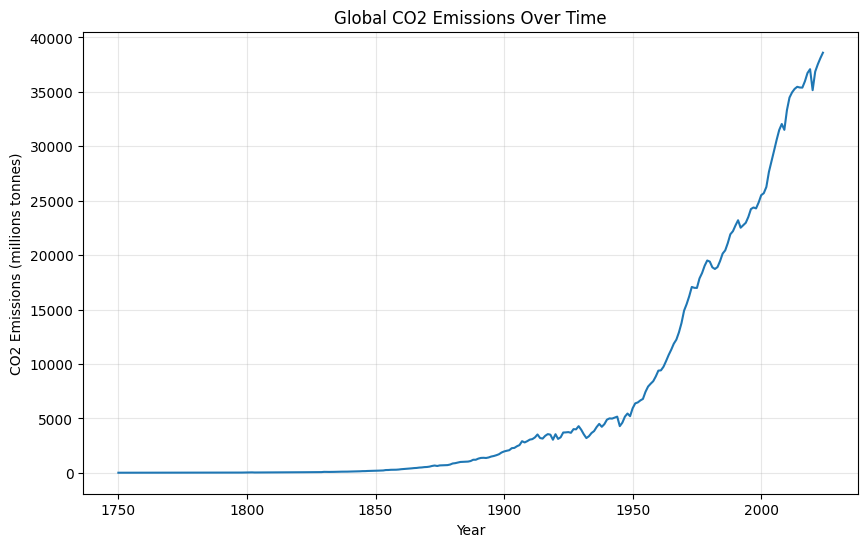

In [8]:
import matplotlib.pyplot as plt
#Full recorded history of emission from dataset (1750-2024)
world=data[data['country']=='World']
world_co2= world[['year', 'co2']].dropna()

#plotting the data
plt.figure(figsize=(10,6))
plt.plot(world_co2['year'], world_co2['co2'])
plt.title("Global CO2 Emissions Over Time")
plt.xlabel('Year')
plt.ylabel("CO2 Emissions (millions tonnes)")
plt.grid(True, alpha=0.3)
plt.show()

There is an increase in CO2 emissions beginning around 1850, and then exponentially increases in 1950.


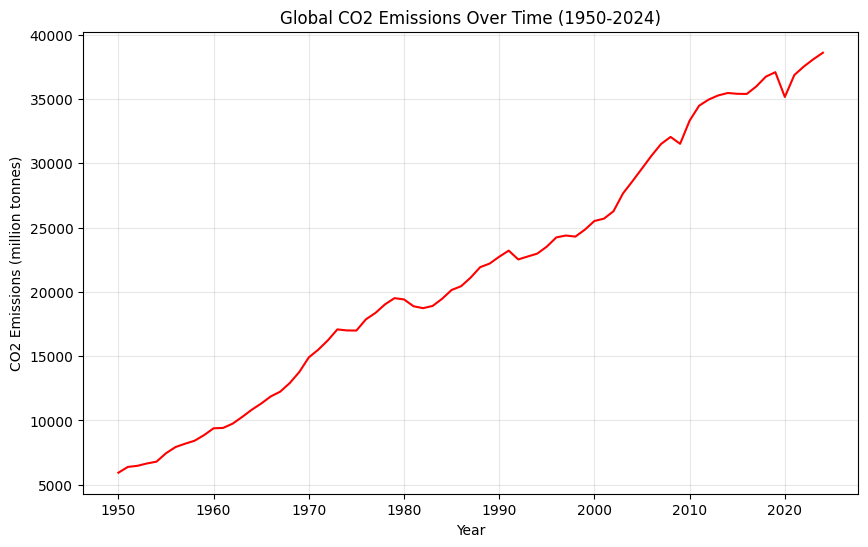

In [9]:
#what about trends in a smaller time window (1950-2024)
new_world= world_co2[world_co2['year']>=1950]
plt.figure(figsize=(10,6))
plt.plot(new_world['year'], new_world['co2'], color='red')
plt.title("Global CO2 Emissions Over Time (1950-2024)")
plt.xlabel('Year')
plt.ylabel('CO2 Emissions (million tonnes)')
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
#UK data for decoupling

uk=data[data['country']=='United Kingdom']
uk_data= uk[['year', 'gdp', 'co2']].dropna()
uk_data.tail(10)

,year,gdp,co2
47771,2013,2.296253e+12,477.611
47772,2014,2.369726e+12,438.807
47773,2015,2.426436e+12,422.461
47774,2016,2.478973e+12,399.430
47775,2017,2.539549e+12,387.367
47776,2018,2.582848e+12,379.730
47777,2019,2.624285e+12,364.753
47778,2020,2.334804e+12,326.263
47779,2021,2.512190e+12,342.366
47780,2022,2.615231e+12,311.118


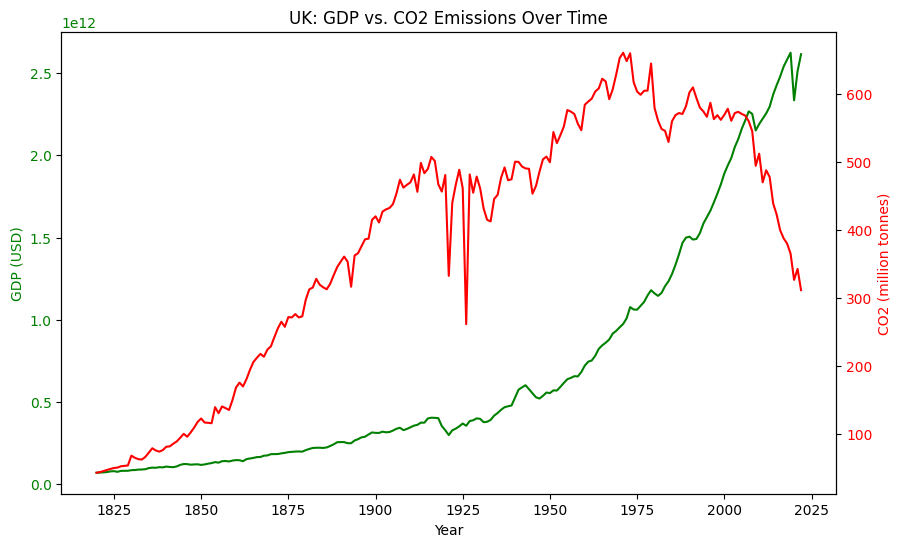

In [11]:
#plot UK decoupling data
uk=data[data['country']=='United Kingdom']
uk_data= uk[['year', 'gdp', 'co2']].dropna()

fig, ax1= plt.subplots(figsize=(10,6))

#GDP axis
ax1.plot(uk_data['year'], uk_data['gdp'], color='green', label='GDP')
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP (USD)', color='green')
ax1.tick_params(axis='y', labelcolor='green')

# Right axis: CO2, sharing the same x-axis
ax2 = ax1.twinx()
ax2.plot(uk_data['year'], uk_data['co2'], color='red', label='CO2')
ax2.set_ylabel('CO2 (million tonnes)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('UK: GDP vs. CO2 Emissions Over Time')
plt.show()
#Please note that this code block was generated by Claude AI

It is possible for a countru to see increase in economic growth and divesting in the infastructure that drives CO2 emissions.


In [12]:
#Across contries, how strongly does GDP per capita relate to per captia CO2 emissions?

#Choose 2022 as there is more complete data
latest_data= data[data['year']==2022]
latest_data= latest_data[latest_data['iso_code'].str.len()==3]

#compute gdp per capita
subset= latest_data[['country', 'gdp','population', 'co2_per_capita']].dropna()
subset['gdp_per_capita'] = subset['gdp'] / subset['population']

subset[['country', 'gdp_per_capita', 'co2_per_capita']].head()


,country,gdp_per_capita,co2_per_capita
272,Afghanistan,1313.577777,0.251
897,Albania,12792.059169,1.591
1072,Algeria,13101.456658,4.239
1522,Angola,4443.555847,0.592
2322,Argentina,18827.435063,4.047


In [13]:
#Correlation Coffiencient between GDP per capita and CO2 per capita
corr= subset['gdp_per_capita'].corr(subset['co2_per_capita'])
print(corr)

0.7454716071585795


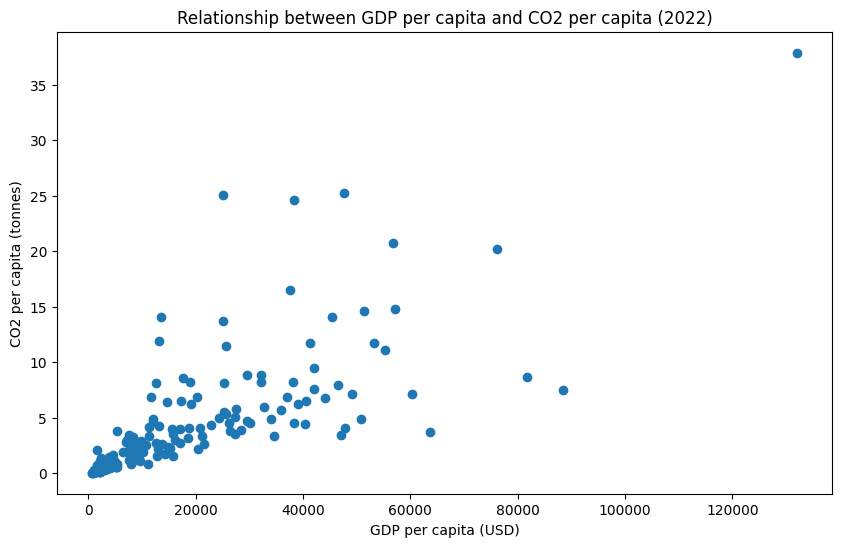

In [14]:
#scatter plot of relationship between GDP per capita and CO2 per capita

plt.figure(figsize=(10,6))

plt.scatter(subset['gdp_per_capita'], subset['co2_per_capita'])
plt.xlabel('GDP per capita (USD)')
plt.ylabel('CO2 per capita (tonnes)')
plt.title('Relationship between GDP per capita and CO2 per capita (2022)')
plt.show()

In [15]:
subset.sort_values('co2_per_capita', ascending=False).head(5)

#High GDP but low emissions
rich=subset[subset['gdp_per_capita']>subset['gdp_per_capita'].quantile(0.75)]
rich.sort_values('co2_per_capita')[['country', 'gdp_per_capita', 'co2_per_capita']].head(8)


,country,gdp_per_capita,co2_per_capita
28881,Malta,34637.146565,3.359
44118,Sweden,47124.891229,3.465
44293,Switzerland,63623.009082,3.748
37783,Portugal,28387.329346,3.909
21117,Hong Kong,47775.870530,4.121
17381,France,40308.887846,4.456
47780,United Kingdom,38358.124233,4.563
26831,Lithuania,30108.830744,4.578


In [16]:
#Regression
latest= data[(data['year']==2022) & (data['iso_code'].str.len() == 3)]
chosen_features=['gdp', 'population', 'coal_co2', 'oil_co2', 'gas_co2', 'cement_co2', 'energy_per_capita', 'energy_per_gdp', 'co2_per_capita' ]
latest[chosen_features].notna().sum()


gdp                  164
population           216
coal_co2             137
oil_co2              213
gas_co2              129
cement_co2           210
energy_per_capita    204
energy_per_gdp       164
co2_per_capita       213
dtype: int64

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

#countries from 2022
model_data= data[(data['year']==2022) & (data['iso_code'].str.len() == 3)]

#GDP per capita
model_data['gdp_per_capita'] = model_data['gdp'] / model_data['population']

columns_used=['gdp_per_capita', 'energy_per_capita', 'energy_per_gdp']
model_data=model_data[['country']+ columns_used+['co2_per_capita']].dropna()

X=model_data[['gdp_per_capita', 'energy_per_capita', 'energy_per_gdp']]
Y=model_data['co2_per_capita']
print("Countries in model:", X.shape[0])
X.head()

Countries in model: 164


C:\Users\coinc\AppData\Local\Temp\ipykernel_22384\1174850301.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_data['gdp_per_capita'] = model_data['gdp'] / model_data['population']


,gdp_per_capita,energy_per_capita,energy_per_gdp
272,1313.577777,1111.573,0.846
897,12792.059169,9148.740,0.715
1072,13101.456658,16145.337,1.232
1522,4443.555847,2739.316,0.616
2322,18827.435063,22049.938,1.171


In [18]:
#Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print("Training set:", X_train.shape[0])
print("Testing set:", X_test.shape[0])

Training set: 131
Testing set: 33


In [19]:
#train the model
model= LinearRegression()
model.fit(X_train, Y_train)

#predict on the test set
Y_pred=model.predict(X_test)

r2= r2_score(Y_test, Y_pred)
RMSE= mean_squared_error(Y_test, Y_pred)**0.5
print("R-squared:", r2)
print("RMSE:", RMSE)

R-squared: 0.430347471544541
RMSE: 3.805311614610688


Minimal feature selection techniques were used. Although feature selection was done in a past project in R.


In [20]:
#Standardize the features for better interpretability of coefficients
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler()
Xtrain_scaled= scaler.fit_transform(X_train)
Xtest_scaled= scaler.transform(X_test)

#train the model on standardized data
model_scaled= LinearRegression()
model_scaled.fit(Xtrain_scaled, Y_train)

for i in range(len(columns_used)):
    print(f"Coefficient for {columns_used[i]}: {model_scaled.coef_[i]}")

Coefficient for gdp_per_capita: -0.11066332332226247
Coefficient for energy_per_capita: 4.931675520945821
Coefficient for energy_per_gdp: 0.5854692221052685
